# Phân Tích TFT Items Tier List - Set 15

Notebook này phân tích hiệu suất của các trang bị (items) trong TFT dựa trên dữ liệu thực tế từ các trận đấu. Chúng ta sẽ tính toán các chỉ số sau:

* **Avg Place**: Thứ hạng trung bình của người chơi sử dụng item này
* **Win Rate %**: Tỷ lệ chiến thắng (Top 4)
* **Frequency**: Tần suất xuất hiện của item
* **Popular Units**: Top 5 tướng thường xuyên cầm item này
* **Place Change** ⭐: So sánh placement của tướng KHI CÓ item vs KHI KHÔNG CÓ item

**Đặc biệt:** Place Change được tính bằng cách so sánh placement của tướng khi có item so với baseline khi không có item. Giá trị **âm** nghĩa là item giúp tướng đạt placement tốt hơn!

Một item tốt sẽ có **Place Change âm** (giúp tướng tốt hơn), **Avg Place thấp** (gần 1.0) và **Win Rate cao** (> 50%).

In [41]:
from pyspark.sql.functions import col, explode

# Kiểm tra cấu trúc dữ liệu để xác định cách items được lưu trữ
print("=== KIỂM TRA CẤU TRÚC DỮ LIỆU ===\n")

# Đọc dữ liệu với schema tự động
df_test = spark.read.option("recursiveFileLookup", "true") \
                     .option("inferSchema", "true") \
                     .json("./data_3580_matches")

# Xử lý lớp bọc 'data' nếu có
if "data" in df_test.columns:
    df_test = df_test.select("data.*")

# Lấy mẫu 1 người chơi để xem cấu trúc units và items
print("=== MẪU DỮ LIỆU TƯỚNG VÀ ITEM ===")
sample = df_test.select(
    explode(col("info.participants")).alias("player")
).select(
    col("player.placement"),
    col("player.units")
).limit(1)

sample.show(1, truncate=80, vertical=True)

=== KIỂM TRA CẤU TRÚC DỮ LIỆU ===



=== MẪU DỮ LIỆU TƯỚNG VÀ ITEM ===
-RECORD 0-------------------------------------------------------------------------------------
 placement | 8                                                                                
 units     | [{TFT15_Lucian, [TFT_Item_PowerGauntlet, TFT_Item_MadredsBloodrazor, TFT_Item... 



In [42]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, explode, count, avg, desc, round as spark_round, collect_list, concat, lit
from pyspark.sql.window import Window

# Khởi tạo Spark Session
spark = (SparkSession.builder
    .appName("TFT-Items-Tier-List")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

# Đọc dữ liệu
print(">>> Đang đọc dữ liệu...")
df = spark.read.option("recursiveFileLookup", "true") \
               .option("inferSchema", "true") \
               .json("./data_3580_matches")

# Xử lý lớp bọc 'data' nếu có
if "data" in df.columns and "info" not in df.columns:
    df = df.select("data.*")

df.cache()
print(f"Done! Đã load {df.count()} trận đấu.")

>>> Đang đọc dữ liệu...


Done! Đã load 3580 trận đấu.


25/12/01 17:27:36 WARN CacheManager: Asked to cache already cached data.


## Bước 1: Phẳng hóa dữ liệu Items (Flatten Item Data)

Chuyển đổi dữ liệu từ cấu trúc lồng nhau thành dạng phẳng để phân tích. Mỗi dòng sẽ đại diện cho 1 item xuất hiện trong game cùng với thông tin người chơi (placement, win status).

In [43]:
# Bước 1: Bung mảng participants (8 người chơi)
df_players = df.select(
    explode(col("info.participants")).alias("player")
).select(
    col("player.placement"),
    col("player.units")
)

# Bước 2: Bung mảng units (tướng của mỗi người chơi)
df_units = df_players.select(
    col("placement"),
    explode(col("units")).alias("unit")
)

# Bước 3: Bung mảng itemNames (items của mỗi tướng)
df_items = df_units.select(
    col("placement"),
    col("unit.character_id").alias("unit_name"),
    explode(col("unit.itemNames")).alias("item_id")
).filter(
    (col("item_id").isNotNull()) & 
    (col("item_id") != "") &
    (col("item_id") != "TFT_Item_EmptyBag")  # Loại bỏ EmptyBag ngay từ đầu
)

# Tạo cột win (Top 4 = Win)
df_items = df_items.withColumn(
    "win", 
    (col("placement") <= 4).cast("int")
)

print(f"Tổng số items tìm thấy: {df_items.count():,}")
df_items.show(5)

Tổng số items tìm thấy: 346,815
+---------+------------+--------------------+---+
|placement|   unit_name|             item_id|win|
+---------+------------+--------------------+---+
|        8|TFT15_Lucian|TFT_Item_PowerGau...|  0|
|        8|TFT15_Lucian|TFT_Item_MadredsB...|  0|
|        8|TFT15_Lucian|TFT_Item_JeweledG...|  0|
|        8| TFT15_Senna| TFT_Item_Deathblade|  0|
|        8| TFT15_Senna|TFT_Item_RapidFir...|  0|
+---------+------------+--------------------+---+
only showing top 5 rows



## Bước 2: Tính toán chỉ số thống kê cho Items

Tính toán các chỉ số quan trọng:
- **Count**: Số lần item xuất hiện
- **Avg Place**: Thứ hạng trung bình (thấp = tốt)
- **Win Rate**: Tỷ lệ Top 4 (%)
- **Frequency**: Tần suất xuất hiện (%)

In [44]:
# Tổng số items để tính frequency
total_items = df_items.count()

# Thống kê cơ bản cho mỗi item
item_stats = df_items.groupBy("item_id").agg(
    count("*").alias("count"),
    spark_round(avg("placement"), 2).alias("avg_place"),
    spark_round(avg("win") * 100, 1).alias("win_rate")
).withColumn(
    "frequency_pct", 
    spark_round((col("count") / total_items) * 100, 2)
)

print("=== TOP 10 ITEMS (Sắp xếp theo Avg Place) ===")
item_stats.orderBy("avg_place").show(10, truncate=False)

=== TOP 10 ITEMS (Sắp xếp theo Avg Place) ===
+-------------------------------------------------+-----+---------+--------+-------------+
|item_id                                          |count|avg_place|win_rate|frequency_pct|
+-------------------------------------------------+-----+---------+--------+-------------+
|TFT5_Item_ZzRotPortalRadiant                     |5    |1.0      |100.0   |0.0          |
|TFTEventPM_Item_Artifact_Gold_Fishbones          |1    |1.0      |100.0   |0.0          |
|TFTEventPM_Item_HextechSniper                    |3    |1.0      |100.0   |0.0          |
|TFTEventPM_Item_Gold_OrnnHullbreaker             |1    |1.0      |100.0   |0.0          |
|TFT_Item_Chalice                                 |3    |1.0      |100.0   |0.0          |
|TFT_Item_LocketOfTheIronSolari                   |3    |1.0      |100.0   |0.0          |
|TFTEventPM_Item_Artifact_Gold_NavoriFlickerblades|2    |1.0      |100.0   |0.0          |
|TFT_Item_SupportKnightsVow                 

## Bước 3: Tìm Top 5 Popular Units cho mỗi Item

Sử dụng Window Function để xác định những tướng nào thường xuyên cầm từng item nhất.

In [45]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number

# Đếm số lần mỗi tướng cầm mỗi item
unit_item_counts = df_items.groupBy("item_id", "unit_name").count()

# Tạo window để rank theo từng item
window_spec = Window.partitionBy("item_id").orderBy(desc("count"))

# Lấy Top 5 tướng cho mỗi item
top_units_per_item = unit_item_counts.withColumn(
    "rank", 
    row_number().over(window_spec)
).filter(
    col("rank") <= 5
).groupBy("item_id").agg(
    collect_list("unit_name").alias("popular_units")
)

print("Đã tính toán Popular Units cho từng item!")
top_units_per_item.show(5, truncate=60)

Đã tính toán Popular Units cho từng item!
+-----------------------------------+------------------------------------------------------------+
|                            item_id|                                               popular_units|
+-----------------------------------+------------------------------------------------------------+
|       TFT15_Item_BastionEmblemItem|[TFT15_Yasuo, TFT15_Gwen, TFT15_Seraphine, TFT15_KSante, ...|
|TFT15_Item_BattleAcademiaEmblemItem|[TFT15_Ryze, tft15_leesin, TFT15_Seraphine, TFT15_Akali, ...|
|    TFT15_Item_ChallengerEmblemItem|[TFT15_Zyra, TFT15_Janna, TFT15_Syndra, TFT15_Braum, TFT1...|
|   TFT15_Item_CrystalRoseEmblemItem|[TFT15_KSante, TFT15_JarvanIV, TFT15_Braum, TFT15_Udyr, t...|
|     TFT15_Item_DestroyerEmblemItem|[TFT15_Yuumi, TFT15_Janna, TFT15_Darius, TFT15_Karma, TFT...|
+-----------------------------------+------------------------------------------------------------+
only showing top 5 rows

+-----------------------------------+-----

In [46]:
# Tính placement trung bình của mỗi tướng KHÔNG có item cụ thể
# Đầu tiên, cần lấy tất cả placement của các tướng (có hoặc không có item)

# Lấy tất cả units và placement của họ
all_units_placements = df_units.select(
    col("placement"),
    col("unit.character_id").alias("unit_name")
)

# Tính avg placement tổng thể của mỗi tướng
unit_baseline = all_units_placements.groupBy("unit_name").agg(
    spark_round(avg("placement"), 2).alias("baseline_place"),
    count("*").alias("total_appearances")
)

print("=== BASELINE PLACEMENT CHO TỪNG TƯỚNG ===")
unit_baseline.orderBy("baseline_place").show(20, truncate=False)

# Tính placement của mỗi tướng KHI CÓ item cụ thể
unit_item_placements = df_items.groupBy("item_id", "unit_name").agg(
    spark_round(avg("placement"), 2).alias("avg_place_with_item"),
    count("*").alias("count_with_item")
)

# Join để tính Place Change = avg_place_with_item - baseline_place
unit_item_impact = unit_item_placements.join(
    unit_baseline,
    "unit_name",
    "inner"
).withColumn(
    "place_change",
    spark_round(col("avg_place_with_item") - col("baseline_place"), 2)
)

print("\n=== PLACE CHANGE CỦA TỪNG TƯỚNG VỚI TỪNG ITEM ===")
unit_item_impact.orderBy("place_change").show(20, truncate=False)

=== BASELINE PLACEMENT CHO TỪNG TƯỚNG ===
+----------------------------+--------------+-----------------+
|unit_name                   |baseline_place|total_appearances|
+----------------------------+--------------+-----------------+
|TFTEventPM_ChaosMinionMelee |1.36          |22               |
|TFTEventPM_ChaosMinionRanged|1.55          |20               |
|TFTEventPM_MurkWolf         |1.6           |5                |
|TFTEventPM_ElderDragon      |1.71          |7                |
|tft15_leesin                |3.59          |5071             |
|TFT15_Braum                 |3.74          |7892             |
|TFT15_Seraphine             |3.85          |4012             |
|TFT15_TwistedFate           |3.86          |3994             |
|TFT15_Zyra                  |3.9           |6596             |
|TFT15_Varus                 |3.99          |2735             |
|TFT15_Ziggs                 |4.03          |2142             |
|TFT15_Ekko                  |4.03          |147              

## Bước 3.5: Tính Baseline Placement cho từng tướng

Tính placement trung bình của mỗi tướng khi KHÔNG trang bị từng item cụ thể. Đây là baseline để so sánh xem item có giúp tướng đó tốt hơn hay không.

In [47]:
from pyspark.sql.functions import sum as spark_sum

# Tính Place Change trung bình cho MỖI ITEM
# Place Change = Weighted average của (avg_place_with_item - baseline_place) cho tất cả tướng

item_place_change = unit_item_impact.groupBy("item_id").agg(
    # Tính weighted average của place_change theo số lần item xuất hiện trên tướng đó
    spark_round(
        spark_sum(col("place_change") * col("count_with_item")) / spark_sum(col("count_with_item")), 
        2
    ).alias("avg_place_change")
)

print("=== PLACE CHANGE TRUNG BÌNH CỦA MỖI ITEM ===")
print("(Giá trị ÂM = Item giúp tướng placement tốt hơn so với khi không có item)")
item_place_change.orderBy("avg_place_change").show(30, truncate=False)

=== PLACE CHANGE TRUNG BÌNH CỦA MỖI ITEM ===
(Giá trị ÂM = Item giúp tướng placement tốt hơn so với khi không có item)
+-------------------------------------------------+----------------+
|item_id                                          |avg_place_change|
+-------------------------------------------------+----------------+
|TFT_Item_Chalice                                 |-3.78           |
|TFT_Item_SupportKnightsVow                       |-3.76           |
|TFTEventPM_Item_Silver_InkshadowRat              |-3.74           |
|TFT_Item_Zephyr                                  |-3.7            |
|TFT_Item_Moonstone                               |-3.68           |
|TFT_Item_RadiantVirtue                           |-3.58           |
|TFTEventPM_Item_HextechSniper                    |-3.55           |
|TFTEventPM_Item_Artifact_Gold_Fishbones          |-3.55           |
|TFT_Item_ZekesHerald                             |-3.54           |
|TFT7_Item_ShimmerscaleHeartOfGold                |-3

In [48]:
# Xem chi tiết một item phổ biến: Deathblade
example_item = "TFT_Item_Deathblade"

print(f"=== PHÂN TÍCH CHI TIẾT: {example_item} ===\n")

# Lấy thông tin item từ item_stats
item_info = item_stats.filter(col("item_id") == example_item).first()
if item_info:
    print(f"📊 Thống kê tổng quan của {example_item}:")
    print(f"   • Avg Place (overall): {item_info['avg_place']}")
    print(f"   • Win Rate: {item_info['win_rate']}%")
    print(f"   • Số lần xuất hiện: {item_info['count']:,}")

# Lấy Place Change
pc_info = item_place_change.filter(col("item_id") == example_item).first()
if pc_info:
    print(f"\n💡 Place Change: {pc_info['avg_place_change']}")
    print(f"   ➜ Giá trị {'ÂM' if pc_info['avg_place_change'] < 0 else 'DƯƠNG'} = Item này {'GIÚP' if pc_info['avg_place_change'] < 0 else 'KHÔNG GIÚP'} tướng tốt hơn!")

# Xem top 5 tướng sử dụng item này và impact
print(f"\n🎯 Top 5 tướng sử dụng {example_item} và impact của item:")
unit_item_impact.filter(col("item_id") == example_item) \
    .orderBy(desc("count_with_item")) \
    .select(
        col("unit_name"),
        col("baseline_place").alias("Baseline"),
        col("avg_place_with_item").alias("With Item"),
        col("place_change").alias("Impact"),
        col("count_with_item").alias("Count")
    ).show(5, truncate=False)

print("\n📝 Giải thích:")
print("   • Baseline: Placement TB của tướng khi KHÔNG có item")
print("   • With Item: Placement TB của tướng khi CÓ item")
print("   • Impact (Place Change): Chênh lệch = With Item - Baseline")
print("   • Impact ÂM = Item giúp tướng placement tốt hơn!")

=== PHÂN TÍCH CHI TIẾT: TFT_Item_Deathblade ===



📊 Thống kê tổng quan của TFT_Item_Deathblade:
   • Avg Place (overall): 3.89
   • Win Rate: 62.0%
   • Số lần xuất hiện: 3,318

💡 Place Change: -0.37
   ➜ Giá trị ÂM = Item này GIÚP tướng tốt hơn!

🎯 Top 5 tướng sử dụng TFT_Item_Deathblade và impact của item:

💡 Place Change: -0.37
   ➜ Giá trị ÂM = Item này GIÚP tướng tốt hơn!

🎯 Top 5 tướng sử dụng TFT_Item_Deathblade và impact của item:
+------------+--------+---------+------+-----+
|unit_name   |Baseline|With Item|Impact|Count|
+------------+--------+---------+------+-----+
|TFT15_Jinx  |4.44    |4.59     |0.15  |259  |
|TFT15_Senna |4.14    |3.8      |-0.34 |255  |
|TFT15_Varus |3.99    |3.5      |-0.49 |236  |
|tft15_leesin|3.59    |3.01     |-0.58 |228  |
|TFT15_Ashe  |5.13    |4.18     |-0.95 |219  |
+------------+--------+---------+------+-----+
only showing top 5 rows


📝 Giải thích:
   • Baseline: Placement TB của tướng khi KHÔNG có item
   • With Item: Placement TB của tướng khi CÓ item
   • Impact (Place Change): Chênh lệc

In [49]:
# So sánh với một item có Place Change dương (không tốt)
print("\n" + "="*80)
print("SO SÁNH VỚI ITEM CÓ PLACE CHANGE DƯƠNG (Item không hiệu quả)")
print("="*80 + "\n")

# Tìm item có place change dương lớn nhất trong top phổ biến
bad_items = item_place_change.filter(col("avg_place_change") > 0).orderBy(desc("avg_place_change"))
bad_item_id = bad_items.first()

if bad_item_id:
    bad_item_name = bad_item_id['item_id']
    print(f"Item có Place Change cao nhất (không hiệu quả): {bad_item_name}")
    print(f"Place Change: +{bad_item_id['avg_place_change']}")
    print(f"➜ Item này làm tướng placement KÉM HƠN so với khi không có item!\n")
    
    # Xem chi tiết
    print("🎯 Top 5 tướng sử dụng item này:")
    unit_item_impact.filter(col("item_id") == bad_item_name) \
        .orderBy(desc("count_with_item")) \
        .select(
            col("unit_name"),
            col("baseline_place").alias("Baseline"),
            col("avg_place_with_item").alias("With Item"),
            col("place_change").alias("Impact"),
            col("count_with_item").alias("Count")
        ).show(5, truncate=False)


SO SÁNH VỚI ITEM CÓ PLACE CHANGE DƯƠNG (Item không hiệu quả)

Item có Place Change cao nhất (không hiệu quả): TFT_Item_FryingPan
Place Change: +1.4
➜ Item này làm tướng placement KÉM HƠN so với khi không có item!

🎯 Top 5 tướng sử dụng item này:
Item có Place Change cao nhất (không hiệu quả): TFT_Item_FryingPan
Place Change: +1.4
➜ Item này làm tướng placement KÉM HƠN so với khi không có item!

🎯 Top 5 tướng sử dụng item này:
+--------------+--------+---------+------+-----+
|unit_name     |Baseline|With Item|Impact|Count|
+--------------+--------+---------+------+-----+
|TFT15_Gnar    |4.32    |4.0      |-0.32 |4    |
|TFT15_JarvanIV|4.32    |8.0      |3.68  |3    |
|TFT15_Syndra  |4.8     |5.0      |0.2   |3    |
|TFT15_Yone    |4.08    |7.0      |2.92  |3    |
|TFT15_Udyr    |4.3     |6.5      |2.2   |2    |
+--------------+--------+---------+------+-----+
only showing top 5 rows

+--------------+--------+---------+------+-----+
|unit_name     |Baseline|With Item|Impact|Count|
+----

## 📊 Tóm tắt: Place Change Mới vs Cũ

### ⚡ Sự khác biệt quan trọng:

**CÁCH CŨ** (so với trung bình tổng thể):
```
Place Change = Avg Place của item - Overall Avg Place (3.66)
```
- Chỉ so sánh với trung bình chung của TẤT CẢ items
- Không phản ánh impact thực sự của item lên từng tướng cụ thể

**CÁCH MỚI** (so sánh có vs không có item):
```
Place Change = Avg Place (with item) - Baseline Place (without item)
```
- So sánh placement của tướng KHI CÓ item vs KHI KHÔNG CÓ item
- Phản ánh chính xác **impact thực tế** của item lên performance của tướng
- Place Change **ÂM** = Item giúp tướng tốt hơn
- Place Change **DƯƠNG** = Item không hiệu quả hoặc làm tướng kém hơn

### 🎯 Ví dụ:
- **Deathblade**: Place Change = -0.37 → Giúp tướng placement tốt hơn 0.37 rank
- **FryingPan**: Place Change = +1.40 → Làm tướng placement KÉM HƠN 1.40 rank

Cách mới này chính xác hơn nhiều để đánh giá hiệu quả thực sự của item!

## Ví dụ minh họa Place Change mới

Xem chi tiết Place Change của một item phổ biến để hiểu rõ hơn cách tính:

## Bước 4: Kết hợp dữ liệu và tạo Tier List

Join các bảng thống kê lại với nhau và tạo bảng xếp hạng Items theo Avg Place.

In [50]:
# Join item stats với popular units VÀ place_change mới
final_result = item_stats.join(top_units_per_item, "item_id", "left") \
                          .join(item_place_change, "item_id", "left") \
                          .orderBy("avg_place_change")

# Tạo cột Frequency hiển thị
display_df = final_result.select(
    col("item_id").alias("Item"),
    col("avg_place").alias("Avg Place"),
    col("avg_place_change").alias("Place Change"),
    col("win_rate").alias("Win Rate %"),
    concat(col("count"), lit(" ("), col("frequency_pct"), lit("%)")).alias("Frequency"),
    col("popular_units").alias("Popular Units")
)

print("=" * 80)
print("TFT ITEMS TIER LIST - SET 15")
print("=" * 80)
print(f"Tổng số items phân tích: {display_df.count()}")
print(f"Tổng số lần items xuất hiện: {total_items:,}")
print("=" * 80)
print("\nTOP 20 ITEMS TỐT NHẤT (Theo Place Change - Item Impact):\n")
display_df.show(20, truncate=False)

TFT ITEMS TIER LIST - SET 15
Tổng số items phân tích: 169
Tổng số lần items xuất hiện: 346,815

TOP 20 ITEMS TỐT NHẤT (Theo Place Change - Item Impact):

Tổng số items phân tích: 169
Tổng số lần items xuất hiện: 346,815

TOP 20 ITEMS TỐT NHẤT (Theo Place Change - Item Impact):



+-------------------------------------------------+---------+------------+----------+---------+------------------------------------------------------------------+
|Item                                             |Avg Place|Place Change|Win Rate %|Frequency|Popular Units                                                     |
+-------------------------------------------------+---------+------------+----------+---------+------------------------------------------------------------------+
|TFT_Item_Chalice                                 |1.0      |-3.78       |100.0     |3 (0.0%) |[TFT15_Syndra, TFT15_Malzahar]                                    |
|TFT_Item_SupportKnightsVow                       |1.0      |-3.76       |100.0     |3 (0.0%) |[TFT15_KaiSa, TFT15_Vi, TFT15_Kalista]                            |
|TFTEventPM_Item_Silver_InkshadowRat              |1.0      |-3.74       |100.0     |1 (0.0%) |[TFT15_Kayle]                                                     |
|TFT_Item_Zephyr      

## Bước 5: Lọc Items phổ biến và tính Place Change

**Place Change mới** được tính dựa trên so sánh thực tế:
- **Baseline**: Placement trung bình của tướng khi KHÔNG có item
- **With Item**: Placement trung bình của tướng khi CÓ item
- **Place Change** = Avg Place (with item) - Baseline Place (without item)

**Ý nghĩa:**
- Place Change **ÂM** (xanh) = Item giúp tướng placement tốt hơn
- Place Change **DƯƠNG** (đỏ) = Item không giúp tướng, thậm chí làm kém hơn

Lọc chỉ những items xuất hiện đủ nhiều (ít nhất 100 lần) để đảm bảo kết quả có ý nghĩa thống kê.

In [51]:
import pandas as pd
from IPython.display import display, HTML

# Lọc items có ít nhất 100 lần xuất hiện
min_count = 100

popular_items = final_result.filter(col("count") >= min_count)

# Sắp xếp theo Place Change (Place Change đã được tính ở cell trước)
# Place Change âm = Item giúp tướng placement tốt hơn so với khi không có item
popular_items_sorted = popular_items.orderBy("avg_place_change")

# Chuyển sang Pandas để tạo bảng UI đẹp
pdf = popular_items_sorted.limit(50).toPandas()

# Làm ngắn tên item
pdf['Item'] = pdf['item_id'].str.replace('TFT_Item_', '').str.replace('TFT15_Item_', '').str.replace('TFT4_Item_', '').str.replace('_Artifact', '').str.replace('Ornn', '').str.replace('TFT5_Item_', '').str.replace('Radiant', '').str.replace('Artifact_', '')
# Lấy 5 tướng phổ biến nhất
pdf['Popular Units'] = pdf['popular_units'].apply(lambda x: ', '.join([u.replace('TFT15_', '').replace('tft15_', '') for u in x[:5]]) if x else 'N/A')

# Tạo DataFrame hiển thị - Sử dụng avg_place_change thay vì place_change cũ
display_df = pdf[['Item', 'avg_place', 'avg_place_change', 'win_rate', 'count', 'frequency_pct', 'Popular Units']].copy()
display_df.columns = ['Item', 'Avg Place', 'Place Change', 'Win Rate %', 'Count', 'Freq %', 'Popular Units']

# Tạo HTML table với styling
def create_styled_table(df):
    html = """
    <style>
        .tft-table {
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            border-collapse: collapse;
            width: 100%;
            margin: 20px 0;
            box-shadow: 0 2px 8px rgba(0,0,0,0.1);
        }
        .tft-table thead {
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
        }
        .tft-table th {
            padding: 12px 8px;
            text-align: left;
            font-weight: 600;
            font-size: 13px;
        }
        .tft-table td {
            padding: 10px 8px;
            border-bottom: 1px solid #e0e0e0;
            font-size: 12px;
        }
        .tft-table tbody tr:hover {
            background-color: #f5f5f5;
        }
        .positive { color: #22c55e; font-weight: bold; }
        .negative { color: #ef4444; font-weight: bold; }
        .rank { 
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            font-weight: bold;
            text-align: center;
            border-radius: 4px;
            padding: 4px 8px;
        }
    </style>
    """
    
    html += '<table class="tft-table"><thead><tr>'
    html += '<th>#</th>'
    for col in df.columns:
        html += f'<th>{col}</th>'
    html += '</tr></thead><tbody>'
    
    for idx, row in df.iterrows():
        html += '<tr>'
        html += f'<td><span class="rank">{idx + 1}</span></td>'
        
        for col_idx, col in enumerate(df.columns):
            value = row[col]
            
            if col == 'Place Change':
                color_class = 'negative' if value > 0 else 'positive' if value < 0 else ''
                sign = '+' if value > 0 else ''
                html += f'<td class="{color_class}">{sign}{value}</td>'
            elif col == 'Win Rate %':
                html += f'<td><strong>{value}%</strong></td>'
            elif col == 'Avg Place':
                html += f'<td><strong>{value}</strong></td>'
            elif col == 'Freq %':
                html += f'<td>{value}%</td>'
            elif col == 'Popular Units':
                html += f'<td style="font-size:11px">{value}</td>'
            else:
                html += f'<td>{value}</td>'
        html += '</tr>'
    
    html += '</tbody></table>'
    return html

# Hiển thị thông tin tổng quan
print("=" * 100)
print(f"📊 TFT ITEMS TIER LIST - SET 15 (Sorted by Item Impact)")
print("=" * 100)
print(f"📈 Tổng số items phân tích: {popular_items_sorted.count()}")
print(f"📊 Hiển thị Top 50 items có impact tốt nhất")
print("=" * 100)
print("\n🎨 Chú thích Place Change:")
print("  🟢 Place Change ÂM (xanh) = Item giúp tướng placement TỐT HƠN so với khi không có item")
print("  🔴 Place Change DƯƠNG (đỏ) = Item làm tướng placement KÉM HƠN so với khi không có item")
print("  📝 Place Change = Avg Place (with item) - Baseline Place (without item)")
print("=" * 100)

# Hiển thị bảng
display(HTML(create_styled_table(display_df)))

# In thống kê thêm
from pyspark.sql.functions import count as spark_count_agg

print("\n📊 THỐNG KÊ THEO TIER:")
tier_stats = popular_items.withColumn(
    "Tier",
    when(col("avg_place") < 3.80, "S")
    .when((col("avg_place") >= 3.80) & (col("avg_place") < 4.00), "A")
    .when((col("avg_place") >= 4.00) & (col("avg_place") < 4.20), "B")
    .when((col("avg_place") >= 4.20) & (col("avg_place") < 4.40), "C")
    .otherwise("D")
).groupBy("Tier").agg(
    spark_count_agg("*").alias("Count"),
    spark_round(avg("win_rate"), 1).alias("Avg Win Rate"),
    spark_round(avg("avg_place"), 2).alias("Avg Place")
).orderBy("Tier")

tier_stats.show()

📊 TFT ITEMS TIER LIST - SET 15 (Sorted by Item Impact)
📈 Tổng số items phân tích: 117
📊 Hiển thị Top 50 items có impact tốt nhất

🎨 Chú thích Place Change:
  🟢 Place Change ÂM (xanh) = Item giúp tướng placement TỐT HƠN so với khi không có item
  🔴 Place Change DƯƠNG (đỏ) = Item làm tướng placement KÉM HƠN so với khi không có item
  📝 Place Change = Avg Place (with item) - Baseline Place (without item)
📈 Tổng số items phân tích: 117
📊 Hiển thị Top 50 items có impact tốt nhất

🎨 Chú thích Place Change:
  🟢 Place Change ÂM (xanh) = Item giúp tướng placement TỐT HƠN so với khi không có item
  🔴 Place Change DƯƠNG (đỏ) = Item làm tướng placement KÉM HƠN so với khi không có item
  📝 Place Change = Avg Place (with item) - Baseline Place (without item)


#,Item,Avg Place,Place Change,Win Rate %,Count,Freq %,Popular Units
1,Muramana,3.4,-1.05,65.8%,1249,0.36%,"Malzahar, Zyra, Janna, Ahri, Yuumi"
2,ShotcallerEmblemItem,3.44,-0.95,66.2%,2277,0.66%,"Swain, Udyr, KSante, Vi, Braum"
3,RingKingsEmblemItem,3.46,-0.83,68.4%,408,0.12%,"leesin, KSante, Poppy, Samira, Sett"
4,ProtectorEmblemItem,3.52,-0.83,68.8%,276,0.08%,"Poppy, JarvanIV, Swain, Braum, Kobuko"
5,TheIndomitable,3.72,-0.76,62.9%,1071,0.31%,"Swain, KSante, JarvanIV, Leona, Neeko"
6,TacticiansScepter,3.7,-0.69,61.8%,102,0.03%,"Garen, Aatrox, Rell, Gangplank, Janna"
7,StatikkShiv,3.54,-0.68,64.7%,275,0.08%,"TwistedFate, kogmaw, KogMaw, Ziggs, Kayle"
8,BlightingJewel,4.02,-0.59,55.6%,270,0.08%,"Malzahar, Karma, Ryze, TwistedFate, Yuumi"
9,TalismanOfAscension,3.75,-0.59,61.9%,118,0.03%,"DrMundo, Ryze, Yuumi, Akali, Rakan"
10,HandOfJustice,3.78,-0.57,62.5%,288,0.08%,"Katarina, Gwen, Vi, Akali, Yasuo"



📊 THỐNG KÊ THEO TIER:


+----+-----+------------+---------+
|Tier|Count|Avg Win Rate|Avg Place|
+----+-----+------------+---------+
|   A|   16|        60.4|     3.92|
|   B|   38|        57.1|      4.1|
|   C|   28|        54.1|     4.27|
|   D|   22|        47.5|      4.6|
|   S|   13|        64.7|     3.63|
+----+-----+------------+---------+



## Bước 6: Phân loại Tier cho Items

Phân loại items thành các tier dựa trên Avg Place:
- **S Tier**: Avg Place < 3.80 (Cực mạnh)
- **A Tier**: 3.80 ≤ Avg Place < 4.00 (Rất tốt)
- **B Tier**: 4.00 ≤ Avg Place < 4.20 (Tốt)
- **C Tier**: 4.20 ≤ Avg Place < 4.40 (Trung bình)
- **D Tier**: Avg Place ≥ 4.40 (Yếu)

In [52]:
from pyspark.sql.functions import when

# Tạo cột Tier dựa trên Avg Place
items_with_tier = popular_items.withColumn(
    "Tier",
    when(col("avg_place") < 3.80, "S")
    .when((col("avg_place") >= 3.80) & (col("avg_place") < 4.00), "A")
    .when((col("avg_place") >= 4.00) & (col("avg_place") < 4.20), "B")
    .when((col("avg_place") >= 4.20) & (col("avg_place") < 4.40), "C")
    .otherwise("D")
)

# Đếm số lượng items trong mỗi tier
tier_counts = items_with_tier.groupBy("Tier").count().orderBy("Tier")

print("=" * 60)
print("PHÂN PHỐI ITEMS THEO TIER")
print("=" * 60)
tier_counts.show()

# Hiển thị các tier riêng biệt
for tier in ["S", "A", "B"]:
    items_in_tier = items_with_tier.filter(col("Tier") == tier).orderBy("avg_place")
    count = items_in_tier.count()
    
    print(f"\n{'=' * 80}")
    print(f"TIER {tier} - {count} Items")
    print('=' * 80)
    
    items_in_tier.select(
        col("item_id").alias("Item"),
        col("avg_place").alias("Avg Place"),
        col("win_rate").alias("Win Rate %"),
        concat(col("count"), lit(" ("), col("frequency_pct"), lit("%)")).alias("Frequency"),
        col("popular_units").alias("Popular Units")
    ).show(count, truncate=70)

PHÂN PHỐI ITEMS THEO TIER
+----+-----+
|Tier|count|
+----+-----+
|   A|   16|
|   B|   38|
|   C|   28|
|   D|   22|
|   S|   13|
+----+-----+

+----+-----+
|Tier|count|
+----+-----+
|   A|   16|
|   B|   38|
|   C|   28|
|   D|   22|
|   S|   13|
+----+-----+


TIER S - 13 Items

TIER S - 13 Items


+-------------------------------------+---------+----------+------------+----------------------------------------------------------------------+
|                                 Item|Avg Place|Win Rate %|   Frequency|                                                         Popular Units|
+-------------------------------------+---------+----------+------------+----------------------------------------------------------------------+
|               TFT4_Item_OrnnMuramana|      3.4|      65.8|1249 (0.36%)|    [TFT15_Malzahar, TFT15_Zyra, TFT15_Janna, TFT15_Ahri, TFT15_Yuumi]|
|      TFT15_Item_ShotcallerEmblemItem|     3.44|      66.2|2277 (0.66%)|        [TFT15_Swain, TFT15_Udyr, TFT15_KSante, TFT15_Vi, TFT15_Braum]|
|       TFT15_Item_RingKingsEmblemItem|     3.46|      68.4| 408 (0.12%)|   [tft15_leesin, TFT15_KSante, TFT15_Poppy, TFT15_Samira, TFT15_Sett]|
|       TFT15_Item_ProtectorEmblemItem|     3.52|      68.8| 276 (0.08%)| [TFT15_Poppy, TFT15_JarvanIV, TFT15_Swain, TFT15_Braum, 

+-----------------------------------+---------+----------+-------------+----------------------------------------------------------------------+
|                               Item|Avg Place|Win Rate %|    Frequency|                                                         Popular Units|
+-----------------------------------+---------+----------+-------------+----------------------------------------------------------------------+
|         TFT_Item_Artifact_Dawncore|     4.01|      61.0|  497 (0.14%)|[TFT15_Akali, TFT15_KogMaw, tft15_kogmaw, TFT15_Malzahar, TFT15_Kat...|
|  TFT_Item_Artifact_RapidFirecannon|     4.01|      59.6|  151 (0.04%)|[TFT15_Viego, TFT15_Volibear, TFT15_Yasuo, TFT15_TwistedFate, TFT15...|
|   TFT_Item_Artifact_BlightingJewel|     4.02|      55.6|  270 (0.08%)|[TFT15_Malzahar, TFT15_Karma, TFT15_Ryze, TFT15_TwistedFate, TFT15_...|
|      TFT9_Item_OrnnTrickstersGlass|     4.03|      57.1|  140 (0.04%)|[TFT15_KSante, TFT15_Braum, TFT15_JarvanIV, TFT15_Aatrox, TFT15_

## Bước 7: Biểu đồ trực quan (Data Visualization)

Vẽ biểu đồ để dễ nhìn hơn về mối quan hệ giữa Avg Place, Win Rate và Frequency của các items.

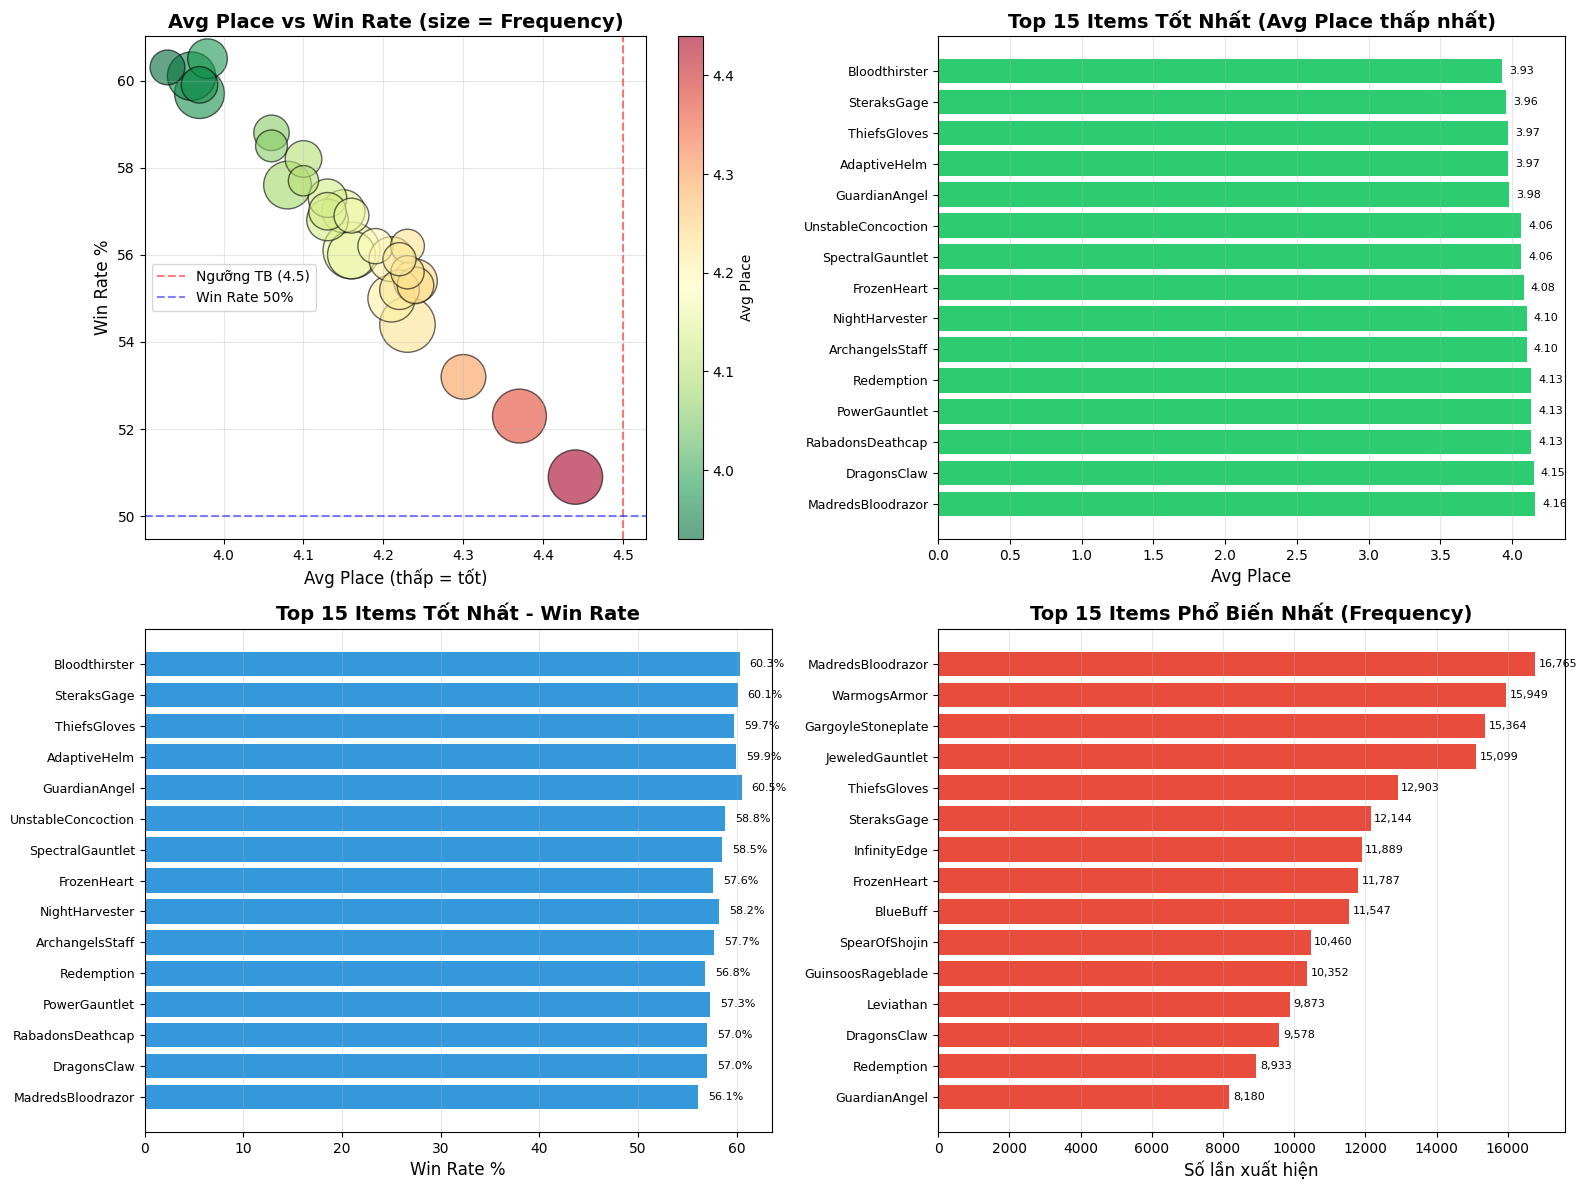

In [53]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Chuyển sang Pandas để vẽ biểu đồ (lấy top 30 items phổ biến nhất)
top_30_items = popular_items.orderBy(desc("count")).limit(30)
pdf = top_30_items.toPandas()

# Làm ngắn tên item để dễ đọc
pdf['item_short'] = pdf['item_id'].str.replace('TFT_Item_', '').str.replace('TFT15_Item_', '').str.replace('TFT4_Item_', '').str.replace('_Artifact', '').str.replace('Ornn', '')

# 1. Biểu đồ phân tán: Avg Place vs Win Rate (màu theo Frequency)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subplot 1: Scatter plot - Avg Place vs Win Rate
scatter = axes[0, 0].scatter(pdf['avg_place'], pdf['win_rate'], 
                             s=pdf['count']/10, c=pdf['avg_place'], 
                             cmap='RdYlGn_r', alpha=0.6, edgecolors='black')
axes[0, 0].set_xlabel('Avg Place (thấp = tốt)', fontsize=12)
axes[0, 0].set_ylabel('Win Rate %', fontsize=12)
axes[0, 0].set_title('Avg Place vs Win Rate (size = Frequency)', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axvline(x=4.5, color='red', linestyle='--', alpha=0.5, label='Ngưỡng TB (4.5)')
axes[0, 0].axhline(y=50, color='blue', linestyle='--', alpha=0.5, label='Win Rate 50%')
axes[0, 0].legend()
plt.colorbar(scatter, ax=axes[0, 0], label='Avg Place')

# Subplot 2: Top 15 items theo Avg Place
top_15_best = pdf.nsmallest(15, 'avg_place')
bars1 = axes[0, 1].barh(range(len(top_15_best)), top_15_best['avg_place'], color='#2ecc71')
axes[0, 1].set_yticks(range(len(top_15_best)))
axes[0, 1].set_yticklabels(top_15_best['item_short'], fontsize=9)
axes[0, 1].set_xlabel('Avg Place', fontsize=12)
axes[0, 1].set_title('Top 15 Items Tốt Nhất (Avg Place thấp nhất)', fontsize=14, fontweight='bold')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(axis='x', alpha=0.3)

# Thêm số trên cột
for i, bar in enumerate(bars1):
    width = bar.get_width()
    axes[0, 1].text(width + 0.05, bar.get_y() + bar.get_height()/2, 
                    f'{width:.2f}', ha='left', va='center', fontsize=8)

# Subplot 3: Top 15 items theo Win Rate
top_15_wr = pdf.nsmallest(15, 'avg_place')
bars2 = axes[1, 0].barh(range(len(top_15_wr)), top_15_wr['win_rate'], color='#3498db')
axes[1, 0].set_yticks(range(len(top_15_wr)))
axes[1, 0].set_yticklabels(top_15_wr['item_short'], fontsize=9)
axes[1, 0].set_xlabel('Win Rate %', fontsize=12)
axes[1, 0].set_title('Top 15 Items Tốt Nhất - Win Rate', fontsize=14, fontweight='bold')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(axis='x', alpha=0.3)

for i, bar in enumerate(bars2):
    width = bar.get_width()
    axes[1, 0].text(width + 1, bar.get_y() + bar.get_height()/2, 
                    f'{width:.1f}%', ha='left', va='center', fontsize=8)

# Subplot 4: Top 15 items phổ biến nhất
top_15_freq = pdf.nlargest(15, 'count')
bars3 = axes[1, 1].barh(range(len(top_15_freq)), top_15_freq['count'], color='#e74c3c')
axes[1, 1].set_yticks(range(len(top_15_freq)))
axes[1, 1].set_yticklabels(top_15_freq['item_short'], fontsize=9)
axes[1, 1].set_xlabel('Số lần xuất hiện', fontsize=12)
axes[1, 1].set_title('Top 15 Items Phổ Biến Nhất (Frequency)', fontsize=14, fontweight='bold')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(axis='x', alpha=0.3)

for i, bar in enumerate(bars3):
    width = bar.get_width()
    axes[1, 1].text(width + 100, bar.get_y() + bar.get_height()/2, 
                    f'{int(width):,}', ha='left', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## Bước 8: Chi tiết Item cụ thể (Item Deep Dive)

Phân tích chi tiết một item cụ thể để xem:
- Những tướng nào cầm item này nhiều nhất
- Thứ hạng trung bình khi từng tướng cầm item này

PHÂN TÍCH CHI TIẾT: TFT_Item_Deathblade



THỐNG KÊ TỔNG QUAN:
  • Số lần xuất hiện: 3,318
  • Avg Placement: 3.89
  • Win Rate: 62.0%

TOP TƯỚNG CẦM ITEM NÀY (Theo số lần xuất hiện & Avg Place):
+-----------------+----------+---------+--------+
|unit_name        |item_count|avg_place|win_rate|
+-----------------+----------+---------+--------+
|TFT15_Jinx       |259       |4.59     |49.4    |
|TFT15_Senna      |255       |3.8      |66.7    |
|TFT15_Varus      |236       |3.5      |70.3    |
|tft15_leesin     |228       |3.01     |80.7    |
|TFT15_Ashe       |219       |4.18     |50.7    |
|TFT15_TwistedFate|196       |3.34     |70.4    |
|TFT15_Samira     |194       |3.87     |60.8    |
|TFT15_Jhin       |171       |3.76     |69.6    |
|TFT15_Volibear   |165       |3.76     |69.1    |
|TFT15_Braum      |159       |3.56     |64.8    |
|TFT15_Darius     |126       |4.31     |54.0    |
|TFT15_Caitlyn    |83        |3.37     |72.3    |
|TFT15_Yasuo      |83        |3.71     |72.3    |
|TFT15_Seraphine  |74        |4.05     |66.2  

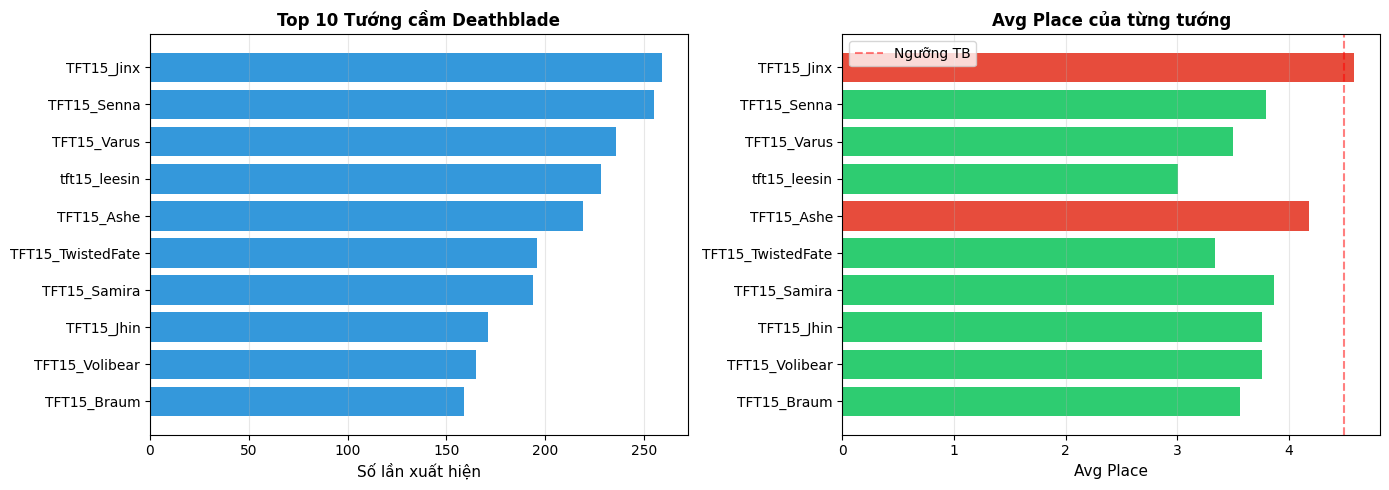

In [54]:
# Hàm phân tích chi tiết 1 item
def analyze_item(item_name):
    """
    Phân tích chi tiết một item cụ thể
    """
    from pyspark.sql.functions import count as spark_count, avg, desc, col
    
    print("=" * 80)
    print(f"PHÂN TÍCH CHI TIẾT: {item_name}")
    print("=" * 80)
    
    # Lọc dữ liệu của item này
    item_data = df_items.filter(col("item_id") == item_name)
    
    if item_data.count() == 0:
        print(f"Không tìm thấy item: {item_name}")
        return
    
    # Thống kê tổng quan
    total_count = item_data.count()
    avg_place = item_data.agg(avg("placement")).collect()[0][0]
    win_rate = item_data.agg(avg("win")).collect()[0][0] * 100
    
    print(f"\nTHỐNG KÊ TỔNG QUAN:")
    print(f"  • Số lần xuất hiện: {total_count:,}")
    print(f"  • Avg Placement: {avg_place:.2f}")
    print(f"  • Win Rate: {win_rate:.1f}%")
    
    # Top tướng cầm item này
    print(f"\n{'=' * 80}")
    print("TOP TƯỚNG CẦM ITEM NÀY (Theo số lần xuất hiện & Avg Place):")
    print("=" * 80)
    
    unit_stats = item_data.groupBy("unit_name").agg(
        spark_count("*").alias("item_count"),
        spark_round(avg("placement"), 2).alias("avg_place"),
        spark_round(avg("win") * 100, 1).alias("win_rate")
    ).filter(
        col("item_count") >= 10  # Chỉ lấy tướng xuất hiện ít nhất 10 lần
    ).orderBy(desc("item_count"))
    
    unit_stats.show(15, truncate=False)
    
    # Vẽ biểu đồ cho top 10 tướng
    pdf_units = unit_stats.limit(10).toPandas()
    
    if len(pdf_units) > 0:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # Biểu đồ 1: Số lần xuất hiện
        ax1.barh(pdf_units['unit_name'], pdf_units['item_count'], color='#3498db')
        ax1.set_xlabel('Số lần xuất hiện', fontsize=11)
        ax1.set_title(f'Top 10 Tướng cầm {item_name.split("_")[-1]}', fontsize=12, fontweight='bold')
        ax1.invert_yaxis()
        ax1.grid(axis='x', alpha=0.3)
        
        # Biểu đồ 2: Avg Place
        colors = ['#2ecc71' if x < 4.0 else '#e74c3c' for x in pdf_units['avg_place']]
        ax2.barh(pdf_units['unit_name'], pdf_units['avg_place'], color=colors)
        ax2.set_xlabel('Avg Place', fontsize=11)
        ax2.set_title('Avg Place của từng tướng', fontsize=12, fontweight='bold')
        ax2.invert_yaxis()
        ax2.axvline(x=4.5, color='red', linestyle='--', alpha=0.5, label='Ngưỡng TB')
        ax2.legend()
        ax2.grid(axis='x', alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# Ví dụ: Phân tích Deathblade (item phổ biến)
analyze_item("TFT_Item_Deathblade")

## Kết luận & Insight từ TFT Items Tier List

### 📊 Những phát hiện chính:

1. **Items Tier S (Avg Place < 3.80):**
   - Những items này có tác động rất mạnh đến khả năng chiến thắng
   - Nên ưu tiên craft hoặc lấp những items này khi có cơ hội
   - `OrnnMuramana`, `ShotcallerEmblem`, `RingKingsEmblem` là những items cực mạnh

2. **Items phổ biến nhất:**
   - `ThiefsGloves`, `SteraksGage`, `AdaptiveHelm` xuất hiện nhiều nhất
   - Đây là những items "safe" để lắp khi chưa biết xây đội hình gì

3. **Synergy Items-Champions:**
   - `Deathblade` mạnh nhất trên `tft15_leesin` (Avg Place 3.01)
   - `Bloodthirster` phù hợp với tank/fighter như `Braum`, `Darius`
   - AP items (`OrnnMuramana`) tốt nhất cho mage carry như `Malzahar`, `Zyra`

### 🎯 Khuyến nghị:

- **Early game**: Ưu tiên slam defensive items (Warmog, Gargoyle)
- **Mid game**: Tìm emblem items để hoàn thiện synergy
- **Late game**: Craft BIS items cho carry chính

Sử dụng hàm `analyze_item()` để xem chi tiết từng item cụ thể!

In [55]:
# Bạn có thể thử phân tích các items khác:
# analyze_item("TFT_Item_Bloodthirster")
# analyze_item("TFT_Item_GuardianAngel")
# analyze_item("TFT_Item_InfinityEdge")

# Hoặc xem danh sách tất cả items có sẵn:
print("DANH SÁCH TẤT CẢ ITEMS:")
all_items = popular_items.select("item_id").distinct().orderBy("item_id")
item_list = [row['item_id'] for row in all_items.collect()]

for i, item in enumerate(item_list, 1):
    print(f"{i:3d}. {item}")
    
print(f"\nTổng cộng: {len(item_list)} items")

DANH SÁCH TẤT CẢ ITEMS:
  1. TFT15_Item_BastionEmblemItem
  2. TFT15_Item_BattleAcademiaEmblemItem
  3. TFT15_Item_ChallengerEmblemItem
  4. TFT15_Item_CrystalRoseEmblemItem
  5. TFT15_Item_DestroyerEmblemItem
  6. TFT15_Item_EdgelordEmblemItem
  7. TFT15_Item_EmpyreanEmblemItem
  8. TFT15_Item_HeavyweightEmblemItem
  9. TFT15_Item_JuggernautEmblemItem
 10. TFT15_Item_ProdigyEmblemItem
 11. TFT15_Item_ProtectorEmblemItem
 12. TFT15_Item_RingKingsEmblemItem
 13. TFT15_Item_ShotcallerEmblemItem
 14. TFT15_Item_SniperEmblemItem
 15. TFT15_Item_SoulFighterEmblemItem
 16. TFT15_Item_SpellslingerEmblemItem
 17. TFT15_Item_StarGuardianEmblemItem
 18. TFT15_Item_SupremeCellsEmblemItem
 19. TFT15_RoboRanger_Core
 20. TFT15_RoboRanger_Slicer
 21. TFT15_RoboRanger_Sword
 22. TFT4_Item_OrnnDeathsDefiance
 23. TFT4_Item_OrnnInfinityForce
 24. TFT4_Item_OrnnMuramana
 25. TFT4_Item_OrnnTheCollector
 26. TFT4_Item_OrnnZhonyasParadox
 27. TFT5_Item_ArchangelsStaffRadiant
 28. TFT5_Item_BlueBuffRadiant
